# Downstream tasks

Loads the compound-level morphology, expression, and equal-variance-contribution
(EVPC) joint embeddings exported by `morphology_expression_integration.ipynb`
(`data/compound_embeddings/`), then:

1. Match Tox21 real-time viability (HepG2) to the shared compounds and build
   response dataframes for `flor` (cell death) and `glo` (metabolic activity)
   at each timepoint. **Primary**: dose-matched DMSO-normalized `% activity`
   near the morphology screen dose (~10 uM). **Secondary**: `curvep_wauc`.
2. Predict each primary response from morphology / expression / joint embeddings
   with nested-CV **elastic net** and **MLP** (mean baseline for reference).
3. Supervised **MoA** prediction (elastic-net multinomial logistic + MLP) with
   per-MoA OOF accuracy heatmap.
4. Supervised **target** prediction from probes-drugs annotations:
   GTOPDB Level-2 family (single-label) and frequent gene targets (multi-label).
5. Predict **gene-set enrichment scores** (heat-shock/UPR and NF-kB — the
   pathways that separate the expression UMAP blobs) from morph / expr / joint. *this is to test whether the observed separation in expression space is also observable from morphology features.*

In [1]:
import json
import os
import re
import time
import unicodedata
import urllib.request
import warnings
from collections import defaultdict
from pathlib import Path

import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.linear_model import ElasticNetCV, LogisticRegressionCV
from sklearn.metrics import mean_absolute_error, r2_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")
plt.rcParams["figure.facecolor"] = "#fcfcfb"
plt.rcParams["axes.facecolor"] = "#fcfcfb"
plt.rcParams["font.size"] = 10

RANDOM_STATE = 0
EMBEDDING_DIR = "./data/compound_embeddings"
PLATE_LEVEL_PARQUET = "./data/plate_level_data/tox21_rt_viability_plate_level.parquet"
ANNOTATION_DIR = (
    "../../data/WS4_data/OpenScreen morphology-20260901T075256Z-1-001/"
    "OpenScreen morphology/annotations/annotations"
)
CELL_LINE = "hepg2"
EXPR_H5AD = "./data/expression_hepg2.h5ad"

## Load compound-level embeddings

Three spaces written by the integration notebook: z-scored morphology PCs,
expression PCs, and the equal-variance-contribution joint concatenation.

In [4]:
emb_morph = ad.read_h5ad(f"{EMBEDDING_DIR}/morphology.h5ad")
emb_expr = ad.read_h5ad(f"{EMBEDDING_DIR}/expression.h5ad")
emb_joint = ad.read_h5ad(f"{EMBEDDING_DIR}/joint_evpc.h5ad")

shared_compounds = emb_morph.obs_names.tolist()
for name, adata in (("expression", emb_expr), ("joint_evpc", emb_joint)):
    if set(adata.obs_names) != set(shared_compounds):
        raise ValueError(f"{name}.h5ad compound set does not match morphology.h5ad")

emb_expr = emb_expr[shared_compounds].copy()
emb_joint = emb_joint[shared_compounds].copy()

morph_z = pd.DataFrame(np.asarray(emb_morph.X), index=shared_compounds)
rna_z = pd.DataFrame(np.asarray(emb_expr.X), index=shared_compounds)
joint_z = np.asarray(emb_joint.X)
moa_shared = emb_morph.obs["Metadata_moa_fine"].astype(str)

print(f"morphology: {morph_z.shape}")
print(f"expression: {rna_z.shape}")
print(f"joint EVPC: {joint_z.shape}")
moa_shared.value_counts().head()

morphology: (119, 30)
expression: (119, 30)
joint EVPC: (119, 60)


Metadata_moa_fine
unclear                           55
DNA synthesis/repair inhibitor    14
MTOR inhibitor                     5
Other MAPK inhibitor               4
CDK inhibitor                      3
Name: count, dtype: int64

## Tox21 viability: HepG2 subset, matched compounds

Load the gathered plate-level table (`gather_plate_level_data.py`). Restrict to
HepG2. Match Tox21 chemicals to the shared compounds by name / synonym /
salt-suffix stripping, CAS, and PubChem synonym expansion (cached).

`flor` = cell death; `glo` = metabolic activity. Median-aggregate replicates to
one row per `(drug, assay, timepoint)`.

In [5]:
import json
import time
import unicodedata
import urllib.request
from collections import defaultdict

EXPR_H5AD = "./data/expression_hepg2.h5ad"
PUBCHEM_CACHE = "./data/plate_level_data/pubchem_synonym_cache.json"
CAS_RE = re.compile(r"^\d{2,7}-\d{2}-\d$")

compounds = pd.read_csv(
    os.path.join(ANNOTATION_DIR, "pd_export_04_2022_2464_compounds_standardized.csv")
).drop_duplicates(subset="name", keep="first")

SALT_SUFFIX_RE = re.compile(
    r"\s+(?:hydrochlorides?|dihydrochloride|trihydrochloride|sulfates?|disulfate|"
    r"bisulfate|mesylate|dimesylate|tosylate|besylate|maleate|fumarate|"
    r"citrate|acetate|phosphate|diphosphate|hydrobromide|dihydrobromide|"
    r"succinate|oxalate|nitrate|lactate|malate|gluconate|tartrate|bitartrate|"
    r"hemihydrate|monohydrate|dihydrate|trihydrate|tetrahydrate|hydrate|"
    r"sodium|potassium|calcium|iodide|bromide|chloride|palmitate|stearate|"
    r"benzoate|carbonate|bicarbonate|pamoate|isethionate|napadisylate|"
    r"edisylate)\s*$",
    re.IGNORECASE,
)


def strip_formulation_suffix(name: str) -> str:
    name = re.sub(r"\s*\([^)]*\)\s*$", "", str(name)).strip()
    prev = None
    while prev != name:
        prev = name
        name = SALT_SUFFIX_RE.sub("", name).strip()
    return name


def normalize_name(name: str) -> str:
    """Casefold, strip accents/punctuation/formulation suffixes for lookup."""
    text = unicodedata.normalize("NFKD", str(name))
    text = "".join(c for c in text if not unicodedata.combining(c))
    text = strip_formulation_suffix(text)
    text = text.casefold().strip()
    text = re.sub(r"\([^)]*\)", " ", text)
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


# --- identity maps for the 119 embedding compounds ---
expr = ad.read_h5ad(EXPR_H5AD)
drug_cid = (
    expr.obs.groupby("Metadata_Drug", observed=True)["pubchem_cid"]
    .first()
    .map(lambda x: int(float(x)) if pd.notna(x) and str(x) not in {"", "nan"} else None)
)

name_to_pdid: dict[str, object] = {}
for _, row in compounds.iterrows():
    for raw in [row["name"], *(str(row["synonyms"] or "").split(";"))]:
        raw = str(raw).strip()
        if not raw or raw.lower() == "nan":
            continue
        for key in {raw.casefold().strip(), normalize_name(raw)}:
            if key:
                name_to_pdid.setdefault(key, row["pdid"])

cas_to_pdid: dict[str, object] = {}
for _, row in compounds.iterrows():
    for cas in str(row["cas"] or "").split(";"):
        cas = cas.strip()
        if CAS_RE.match(cas):
            cas_to_pdid.setdefault(cas, row["pdid"])

drug_to_pdid = {}
for d in shared_compounds:
    for key in {d.casefold().strip(), normalize_name(d)}:
        if key in name_to_pdid:
            drug_to_pdid[d] = name_to_pdid[key]
            break
    else:
        drug_to_pdid[d] = None
pdid_to_drug = {p: d for d, p in drug_to_pdid.items() if p is not None}

# PubChem synonym/CAS expansion (cached) for every embedding drug.
pubchem_cache: dict[str, list[str]] = {}
if os.path.exists(PUBCHEM_CACHE):
    pubchem_cache = json.loads(Path(PUBCHEM_CACHE).read_text(encoding="utf-8"))


def fetch_pubchem_synonyms(cid: int) -> list[str]:
    key = str(cid)
    if key in pubchem_cache:
        return pubchem_cache[key]
    url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{cid}/synonyms/JSON"
    with urllib.request.urlopen(url, timeout=60) as resp:
        syns = json.load(resp)["InformationList"]["Information"][0].get("Synonym", [])
    pubchem_cache[key] = syns
    time.sleep(0.2)
    return syns


# Build reverse indexes: tox lookup keys -> drug
norm_to_drug: dict[str, str] = {}
cas_to_drug: dict[str, str] = {}
match_source: dict[str, str] = {}

for drug, pdid in drug_to_pdid.items():
    if pdid is None:
        continue
    # names already known
    for raw in [drug, compounds.loc[compounds["pdid"] == pdid, "name"].iloc[0]]:
        for key in {str(raw).casefold().strip(), normalize_name(raw)}:
            norm_to_drug.setdefault(key, drug)
    syn_field = compounds.loc[compounds["pdid"] == pdid, "synonyms"]
    if len(syn_field) and pd.notna(syn_field.iloc[0]):
        for syn in str(syn_field.iloc[0]).split(";"):
            syn = syn.strip()
            if syn:
                for key in {syn.casefold().strip(), normalize_name(syn)}:
                    norm_to_drug.setdefault(key, drug)
    for cas in str(compounds.loc[compounds["pdid"] == pdid, "cas"].iloc[0] or "").split(";"):
        cas = cas.strip()
        if CAS_RE.match(cas):
            cas_to_drug.setdefault(cas, drug)

    cid = drug_cid.get(drug)
    if cid is None:
        continue
    try:
        syns = fetch_pubchem_synonyms(int(cid))
    except Exception:
        continue
    for syn in syns:
        if CAS_RE.match(syn):
            cas_to_drug.setdefault(syn, drug)
        else:
            for key in {syn.casefold().strip(), normalize_name(syn)}:
                if key:
                    norm_to_drug.setdefault(key, drug)

Path(PUBCHEM_CACHE).write_text(json.dumps(pubchem_cache, indent=2), encoding="utf-8")
print(
    f"Identity indexes: {len(norm_to_drug):,} name keys, {len(cas_to_drug):,} CAS keys "
    f"for {sum(v is not None for v in drug_to_pdid.values())}/{len(shared_compounds)} compounds"
)

plate = pd.read_parquet(PLATE_LEVEL_PARQUET)
plate = plate.loc[plate["cell_line"] == CELL_LINE].copy()
print(f"Plate-level rows for {CELL_LINE}: {len(plate):,}")


def match_row(name: str, cas: str) -> tuple[str | None, str | None]:
    for key in {str(name).casefold().strip(), normalize_name(name)}:
        if key in norm_to_drug:
            return norm_to_drug[key], "name"
    if str(cas) in cas_to_drug:
        return cas_to_drug[str(cas)], "cas"
    return None, None


matched_drug = []
matched_how = []
for name, cas in zip(plate["Chemical.Name"], plate["CAS"]):
    drug, how = match_row(name, cas)
    matched_drug.append(drug)
    matched_how.append(how)

plate["drug"] = matched_drug
plate["match_how"] = matched_how
plate["Metadata_pdid"] = plate["drug"].map(drug_to_pdid)

matched = plate.dropna(subset=["drug"]).copy()
how_counts = matched.drop_duplicates("drug")["match_how"].value_counts().to_dict()
present = sorted(matched["drug"].unique())
absent = sorted(set(shared_compounds) - set(present))
print(
    f"Matched to embeddings: {len(matched):,} rows, "
    f"{len(present)}/{len(shared_compounds)} compounds "
    f"(first-hit by {how_counts})"
)
print(f"Absent from this Tox21 export (not a naming miss): {len(absent)}")
print(absent)

ID_COLS = ["drug", "Metadata_pdid", "CAS", "Chemical.Name"]
CONDITION_COLS = ["cell_line", "assay", "timepoint", "timepoint_h"]
# Dose-matched % activity near morphology screen (~10 uM):
# conc11 ~ 6.8 uM, conc12 ~ 15.3 uM. Mean of the two = resp_near_10uM.
matched["resp_near_10uM"] = matched[["resp11", "resp12"]].mean(axis=1)

OUTCOME_COLS = [
    "resp11",
    "resp12",
    "resp_near_10uM",
    "curvep_wauc",
    "curvep_pod",
    "curvep_ec50",
    "curvep_cmax",
    "Emax",
    "LogAC50",
    "Hill.Coef",
    "Curve.Class2",
    "R2",
    "p.value",
]
GROUP_KEYS = ["drug", "cell_line", "assay", "timepoint", "timepoint_h"]

g = matched.groupby(GROUP_KEYS, dropna=False)
processed = g[OUTCOME_COLS].median().reset_index()
firsts = g[["Chemical.Name", "CAS", "Metadata_pdid"]].first().reset_index()
counts = g.size().rename("n_replicates").reset_index()
processed = processed.merge(firsts, on=GROUP_KEYS).merge(counts, on=GROUP_KEYS)
processed = processed[ID_COLS + CONDITION_COLS + OUTCOME_COLS + ["n_replicates"]]

out_path = "./data/plate_level_data/tox21_rt_viability_hepg2_matched.parquet"
processed.to_parquet(out_path, index=False)
print(f"Wrote {out_path}: {processed.shape[0]:,} rows x {processed.shape[1]} cols")
print(
    processed.groupby(["assay", "timepoint"]).size().unstack(fill_value=0)
    .reindex(columns=["0h", "8h", "16h", "24h", "32h", "40h"])
)
processed.head()

Identity indexes: 26,113 name keys, 221 CAS keys for 119/119 compounds
Plate-level rows for hepg2: 133,416
Matched to embeddings: 1,788 rows, 62/119 compounds (first-hit by {'name': 61, 'cas': 1})
Absent from this Tox21 export (not a naming miss): 57
['AT7519', 'AZD-8055', 'AZD2858', 'Abiraterone acetate', 'Alpelisib', 'Amsacrine', 'Belumosudil', 'Bergenin', 'Binimetinib', 'Brivudine', 'Canagliflozin', 'Capivasertib', 'Capmatinib', 'Dabrafenib', 'Daidzin', 'Dapagliflozin', 'EX229', 'Encorafenib', 'Erdafitinib', 'Filgotinib', 'Glasdegib', 'Homoharringtonine', 'Infigratinib', 'Ipatasertib', 'Ixazomib', 'LY-2584702 (tosylate salt)', 'LY2090314', 'Larotrectinib sulfate', 'MK-3903', 'Macitentan', 'Neratinib', 'OTS514', 'PF-06260933', 'PH-797804', 'Paclitaxel', 'Pemetrexed', 'Ponatinib', 'Ralimetinib dimesylate', 'Rapamycin', 'Regorafenib', 'Relugolix', 'Ribociclib', 'Rucaparib (phosphate)', 'Sapanisertib', 'Silodosin', 'Sonidegib', 'TAK-733', 'Tofacitinib', 'Tomivosertib', 'Trametinib (DMSO

,drug,Metadata_pdid,CAS,Chemical.Name,cell_line,assay,timepoint,timepoint_h,resp11,resp12,...,curvep_pod,curvep_ec50,curvep_cmax,Emax,LogAC50,Hill.Coef,Curve.Class2,R2,p.value,n_replicates
0,18β-Glycyrrhetinic acid,PD014316,471-53-4,Glycyrrhetinic acid,hepg2,flor,0h,0,1.071360,-1.485852,...,-4.119644,-4.119644,0.000000,0.000000,NaN,NaN,4.0,NaN,NaN,1
1,18β-Glycyrrhetinic acid,PD014316,471-53-4,Glycyrrhetinic acid,hepg2,flor,16h,16,-4.015260,-4.804977,...,-4.119644,-4.119644,0.000000,29.255506,-4.214961,4.954917,4.0,0.752762,0.018702,1
2,18β-Glycyrrhetinic acid,PD014316,471-53-4,Glycyrrhetinic acid,hepg2,flor,24h,24,-4.510926,-5.909232,...,-4.176285,-4.294402,29.834878,37.072878,-4.264961,4.954917,2.4,0.783278,0.011077,1
3,18β-Glycyrrhetinic acid,PD014316,471-53-4,Glycyrrhetinic acid,hepg2,flor,32h,32,-5.249079,2.272060,...,-4.146106,-4.294402,27.047778,33.513297,-4.214961,4.954917,2.4,0.838896,0.003118,1
4,18β-Glycyrrhetinic acid,PD014316,471-53-4,Glycyrrhetinic acid,hepg2,flor,40h,40,-5.714890,-6.876468,...,-4.170479,-4.294402,29.254937,37.200509,-4.214961,4.954917,2.4,0.754840,0.018060,1


## Response dataframes (dose-matched % activity + wAUC)

**Normalization is already done upstream.** `resp0`–`resp14` are DMSO-normalized
% activity. Morphology / expression embeddings are from a **~10 uM** screen;
the nearest Tox21 doses are `resp11` (~6.8 uM) and `resp12` (~15.3 uM).

**Primary target** `resp_near_10uM` = mean(`resp11`, `resp12`) — dose-matched
% activity for `flor` (cell death) and `glo` (metabolic activity) at each
timepoint.

**Secondary** `curvep_wauc` — Curvep weighted AUC over the full titration
(kept for comparison; not dose-matched).

Wide tables: one row per matched drug, columns `{assay}_{timepoint}`.

In [124]:
TIMEPOINTS = ["0h", "8h", "16h", "24h", "32h", "40h"]
ASSAYS = ["flor", "glo"]  # flor=cell death, glo=metabolic activity
TARGET_COLS = [f"{a}_{t}" for a in ASSAYS for t in TIMEPOINTS]


def wide_from_outcome(outcome_col: str) -> pd.DataFrame:
    long = processed.loc[
        processed["assay"].isin(ASSAYS) & processed["timepoint"].isin(TIMEPOINTS),
        ["drug", "assay", "timepoint", outcome_col],
    ].copy()
    long["target"] = long["assay"] + "_" + long["timepoint"]
    return (
        long.pivot_table(index="drug", columns="target", values=outcome_col, aggfunc="median")
        .reindex(columns=TARGET_COLS)
        .sort_index()
    )


y_response = wide_from_outcome("resp_near_10uM")  # primary: dose-matched % activity
y_wauc = wide_from_outcome("curvep_wauc")  # secondary: full-curve wAUC

viable_drugs = y_response.dropna().index.tolist()
missing_any = sorted(set(y_response.index) - set(viable_drugs))
print(
    f"Primary resp_near_10uM: {y_response.shape[0]} drugs x {y_response.shape[1]} targets "
    f"({len(viable_drugs)} complete; {len(missing_any)} with any NA)"
)
print("Dose context: resp11~6.8 uM, resp12~15.3 uM (morphology screen ~10 uM)")
print(y_response.describe().round(2).T[["count", "mean", "std", "min", "max"]])
print("\nSecondary curvep_wauc describe:")
print(y_wauc.loc[viable_drugs].describe().round(2).T[["count", "mean", "std", "min", "max"]])

resp_path = "./data/plate_level_data/tox21_hepg2_resp_near10uM_wide.parquet"
wauc_path = "./data/plate_level_data/tox21_hepg2_wauc_response_wide.parquet"
y_response.to_parquet(resp_path)
y_wauc.to_parquet(wauc_path)
print(f"Wrote {resp_path}")
print(f"Wrote {wauc_path}")
y_response.head()

Primary resp_near_10uM: 62 drugs x 12 targets (62 complete; 0 with any NA)
Dose context: resp11~6.8 uM, resp12~15.3 uM (morphology screen ~10 uM)
          count   mean    std    min     max
target                                      
flor_0h    62.0  -0.98   5.69 -22.36   10.85
flor_8h    62.0   0.48   7.19 -13.77   36.59
flor_16h   62.0   1.53  12.14 -14.89   84.68
flor_24h   62.0   4.81  22.88 -13.30  146.75
flor_32h   62.0   8.10  34.82 -11.16  200.37
flor_40h   62.0  11.07  43.29  -9.45  236.39
glo_0h     62.0  -1.93  10.60 -63.33   11.57
glo_8h     62.0  -1.82   3.78 -15.94    4.91
glo_16h    62.0  -3.17   6.60 -30.36    4.21
glo_24h    62.0  -4.79   9.56 -45.01    2.97
glo_32h    62.0  -5.56  12.86 -74.54    2.81
glo_40h    62.0  -5.29  14.16 -86.76    2.59

Secondary curvep_wauc describe:
          count   mean     std     min      max
target                                         
flor_0h    62.0   0.12    0.93    0.00     7.35
flor_8h    62.0   3.76   17.57    0.00   134.32

target,flor_0h,flor_8h,flor_16h,flor_24h,flor_32h,flor_40h,glo_0h,glo_8h,glo_16h,glo_24h,glo_32h,glo_40h
drug,,,,,,,,,,,,
18β-Glycyrrhetinic acid,-0.207246,1.370059,-4.410119,-5.210079,-1.488510,-6.295679,-1.954633,-0.317191,0.030743,0.101124,0.505532,-0.842481
5-Fluorouracil,0.199000,1.189707,1.115941,2.112959,2.654250,3.483806,2.686336,0.672261,-0.762274,-1.871774,-1.122397,-2.117820
8-Hydroxyquinoline,0.503337,2.757415,8.298044,50.304291,93.340266,126.917908,-0.271812,-5.766937,-15.256987,-25.155435,-31.175737,-31.562957
Acetohexamide,-3.024635,-7.441144,-6.951223,-5.071954,-6.390581,-4.223035,3.179139,1.067452,1.143327,0.640686,0.701195,-0.282865
Aliskiren,-0.589754,-1.557031,-6.185843,-1.540530,-3.262543,0.024349,-8.881877,-0.411089,0.723247,0.700943,0.613811,0.727295


In [125]:
# Sanity-check dose-matched % activity vs full-curve wAUC on matched compounds.
print("resp_near_10uM (primary) — should look like %% activity, centered near 0:")
print(y_response.stack().describe().round(2).to_string())
print("\ncurvep_wauc (secondary) — AUC summary; larger magnitude, many zeros:")
print(y_wauc.loc[viable_drugs].stack().describe().round(2).to_string())
print(
    f"\nPairwise Spearman (drug-level) between endpoints, median over targets: "
    f"{pd.Series({c: y_response[c].corr(y_wauc[c], method='spearman') for c in TARGET_COLS}).median():.3f}"
)

resp_near_10uM (primary) — should look like %% activity, centered near 0:
count    744.00
mean       0.20
std       19.83
min      -86.76
25%       -3.84
50%       -0.55
75%        1.59
max      236.39

curvep_wauc (secondary) — AUC summary; larger magnitude, many zeros:
count     744.00
mean        4.74
std        65.26
min      -435.77
25%         0.00
50%         0.00
75%         0.00
max      1156.82

Pairwise Spearman (drug-level) between endpoints, median over targets: 0.433


## Predict flor / glo dose-matched % activity from embeddings

Primary targets: **`resp_near_10uM`** (`flor_*` cell death, `glo_*` metabolic
activity) — already DMSO-normalized % activity near ~10 uM. Secondary wide
table `y_wauc` is available but not used in this CV grid.

For each of the 12 primary responses, run nested K-fold CV:

- **Elastic net** (`ElasticNetCV`): inner CV over `l1_ratio` / `alpha`
- **MLP** (`MLPRegressor` + `GridSearchCV` over width / L2)
- **Mean baseline**: predict the training-fold mean (original scale)

Features: morphology PCs, expression PCs, and EVPC joint space.
Metrics on out-of-fold predictions: **Spearman rho**, **R2**, **MAE**.

In [ ]:
# Preserve embedding order but restrict to complete-response drugs.
viable_order = [d for d in shared_compounds if d in set(viable_drugs)]
y_mat = y_response.loc[viable_order]
X_spaces: dict[str, np.ndarray] = {
    "morphology": morph_z.loc[viable_order].to_numpy(),
    "expression": rna_z.loc[viable_order].to_numpy(),
    "joint": pd.DataFrame(joint_z, index=shared_compounds).loc[viable_order].to_numpy(),
}
targets = list(y_mat.columns)
print(f"Predicting {len(targets)} resp_near_10uM targets for n={len(viable_order)} compounds")

N_OUTER = 5
outer_cv = KFold(n_splits=N_OUTER, shuffle=True, random_state=RANDOM_STATE)
inner_cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)


def fit_elasticnet_reg(X_train: np.ndarray, y_train: np.ndarray) -> ElasticNetCV:
    return ElasticNetCV(
        l1_ratio=[0.15, 0.5, 0.85],
        # alphas=None,
        cv=inner_cv,
        max_iter=5000,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ).fit(X_train, y_train)


def fit_mlp_reg(X_train: np.ndarray, y_train: np.ndarray) -> MLPRegressor:
    search = GridSearchCV(
        MLPRegressor(
            activation="relu",
            solver="adam",
            max_iter=800,
            random_state=RANDOM_STATE,
        ),
        param_grid={
            "hidden_layer_sizes": [(32,), (64, 32)],
            "alpha": [1e-4, 1e-3],
        },
        cv=inner_cv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
        refit=True,
    )
    search.fit(X_train, y_train)
    return search.best_estimator_


def oof_regression(X: np.ndarray, y: np.ndarray, fit_fn) -> np.ndarray:
    pred = np.empty(len(y), dtype=float)
    for train_idx, test_idx in outer_cv.split(X):
        pred[test_idx] = fit_fn(X[train_idx], y[train_idx]).predict(X[test_idx])
    return pred


def mean_baseline_oof(y: np.ndarray) -> np.ndarray:
    pred = np.empty(len(y), dtype=float)
    dummy = np.zeros((len(y), 1))
    for train_idx, test_idx in outer_cv.split(dummy):
        pred[test_idx] = float(np.mean(y[train_idx]))
    return pred


def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    if np.allclose(y_true, y_true[0]):
        rho = float("nan")
    else:
        rho = float(spearmanr(y_true, y_pred).correlation)
    return {
        "spearman": rho,
        "r2": float(r2_score(y_true, y_pred)),
        "mae": float(mean_absolute_error(y_true, y_pred)),
    }


rows: list[dict] = []
oof_store: dict[tuple[str, str, str], np.ndarray] = {}

# To save 40h predictions, we must find which targets are 40h and then save/store those
# For convenience, let's define the 40h target columns.
preds_40h = {}  # This will be filled with predictions for each space/model/target for 40h only

for target in targets:
    y = y_mat[target].to_numpy(dtype=float)
    base_pred = mean_baseline_oof(y)
    oof_store[("baseline", "mean", target)] = base_pred
    for metric, val in regression_metrics(y, base_pred).items():
        rows.append(
            {"target": target, "space": "baseline", "model": "mean", "metric": metric, "value": val}
        )

    for space_name, X in X_spaces.items():
        for model_name, fit_fn in (("elasticnet", fit_elasticnet_reg), ("mlp", fit_mlp_reg)):
            pred = oof_regression(X, y, fit_fn)
            oof_store[(space_name, model_name, target)] = pred
            # Store predictions for 40h only
            if target.endswith("_40h"):
                preds_40h[(space_name, model_name, target)] = {
                    "observed": y.copy(),
                    "predicted": pred.copy(),
                    "drug": viable_order,  # preserve mapping order
                }
            for metric, val in regression_metrics(y, pred).items():
                rows.append(
                    {
                        "target": target,
                        "space": space_name,
                        "model": model_name,
                        "metric": metric,
                        "value": val,
                    }
                )
    print(f"done {target}")

viability_metrics = pd.DataFrame(rows)
viability_spearman = (
    viability_metrics.loc[viability_metrics["metric"] == "spearman"]
    .assign(label=lambda d: d["space"] + " / " + d["model"])
    .pivot(index="label", columns="target", values="value")
)
row_order = [
    "baseline / mean",
    "morphology / elasticnet",
    "morphology / mlp",
    "expression / elasticnet",
    "expression / mlp",
    "joint / elasticnet",
    "joint / mlp",
]
col_order = [f"{a}_{t}" for a in ASSAYS for t in TIMEPOINTS]
viability_spearman = viability_spearman.reindex(index=row_order, columns=col_order)
# print("\nOOF Spearman rho:")
# viability_spearman.round(3)

# --- SAVE 40h predictions ---
# Collect all predictions for 40h targets into a DataFrame and save
preds_40h_rows = []
for (space, model, target), dct in preds_40h.items():
    for obs, pred, drug in zip(dct["observed"], dct["predicted"], dct["drug"]):
        preds_40h_rows.append({
            "space": space,
            "model": model,
            "target": target,
            "drug": drug,
            "observed": obs,
            "predicted": pred,
        })
df_preds_40h = pd.DataFrame(preds_40h_rows)
# Save to disk
preds_40h_path = "./data/predictions/resp10uM_40h_predictions.parquet"
df_preds_40h.to_parquet(preds_40h_path)
print(f"Saved 40h predictions to {preds_40h_path}")

Predicting 12 resp_near_10uM targets for n=62 compounds
done flor_0h
done flor_8h
done flor_16h
done flor_24h
done flor_32h
done flor_40h
done glo_0h
done glo_8h
done glo_16h
done glo_24h
done glo_32h
done glo_40h


OSError: Cannot save file into a non-existent directory: 'results'

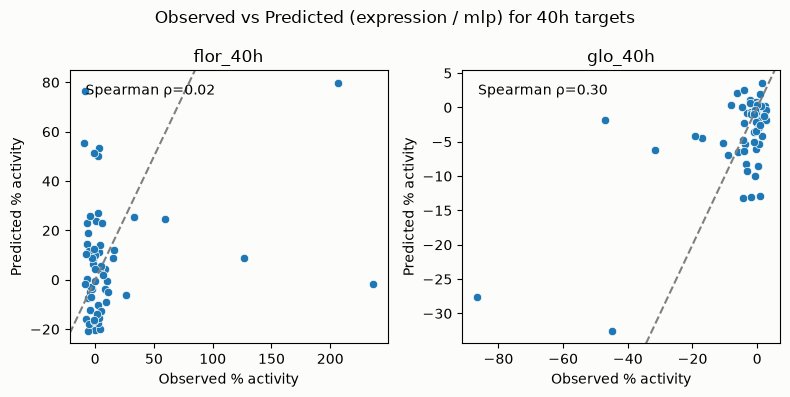

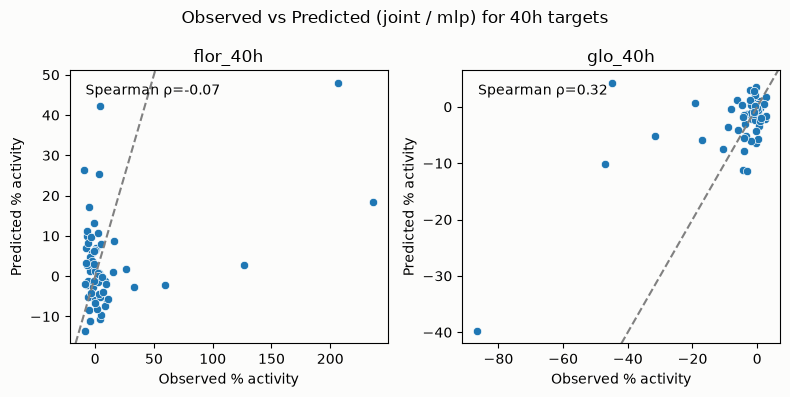

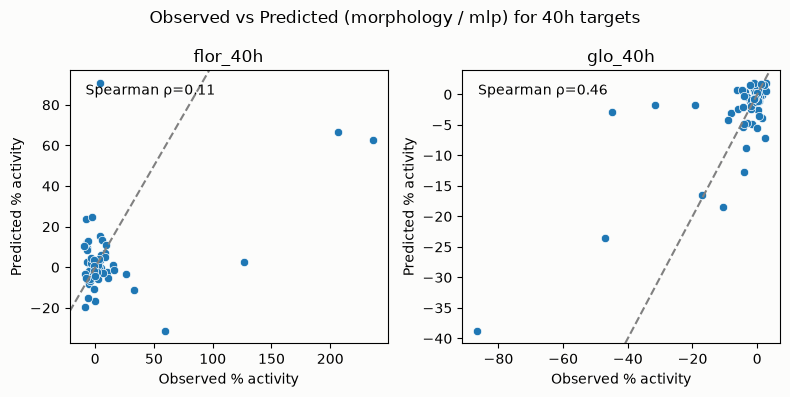

In [150]:
# --- SCATTERPLOT for observed vs predicted, separate plots per space (e.g., joint/elasticnet, all 40h targets) ---
import seaborn as sns
import matplotlib.pyplot as plt

# Pick the model to plot, e.g., "mlp"
model_name = "mlp"
to_plot = df_preds_40h.query(f'model=="{model_name}"')

for space_name, df_space in to_plot.groupby("space"):
    n_targets = df_space["target"].nunique()
    fig, axs = plt.subplots(1, n_targets, figsize=(4 * n_targets, 4))
    if n_targets == 1:
        axs = [axs]

    for ax, (target, group) in zip(axs, df_space.groupby("target")):
        sns.scatterplot(ax=ax, data=group, x="observed", y="predicted")
        ax.axline((0, 0), slope=1, color='grey', linestyle='--')
        ax.set_title(target)
        ax.set_xlabel("Observed % activity")
        ax.set_ylabel("Predicted % activity")
        rho = spearmanr(group["observed"], group["predicted"]).correlation
        ax.text(0.05, 0.95, f"Spearman ρ={rho:.2f}", ha="left", va="top", transform=ax.transAxes)

    fig.suptitle(f"Observed vs Predicted ({space_name} / {model_name}) for 40h targets")
    plt.tight_layout()
    plt.show()

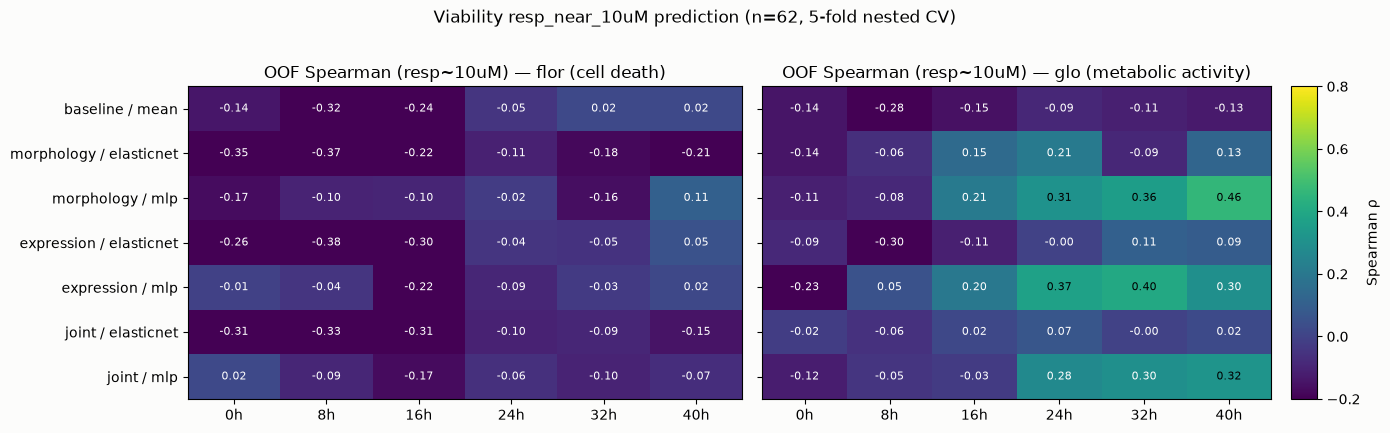

In [142]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), sharey=True)
ims = []
for ax, assay, title in zip(
    axes,
    ASSAYS,
    ["flor (cell death)", "glo (metabolic activity)"],
):
    cols = [c for c in viability_spearman.columns if c.startswith(assay + "_")]
    mat = viability_spearman[cols]
    im = ax.imshow(mat.to_numpy(), aspect="auto", vmin=-0.2, vmax=0.8, cmap="viridis")
    ims.append(im)
    ax.set_xticks(range(len(cols)))
    ax.set_xticklabels([c.split("_", 1)[1] for c in cols], rotation=0)
    ax.set_yticks(range(len(mat.index)))
    ax.set_yticklabels(mat.index)
    ax.set_title(f"OOF Spearman (resp~10uM) — {title}")
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat.iloc[i, j]
            if np.isnan(val):
                continue
            ax.text(
                j, i, f"{val:.2f}",
                ha="center", va="center",
                color="white" if val < 0.3 else "black",
                fontsize=8,
            )

# Move colorbar to the right OUTSIDE all axes
divider = make_axes_locatable(axes[-1])
cax = divider.append_axes("right", size="5%", pad=0.2)
cbar = fig.colorbar(ims[-1], cax=cax)
cbar.set_label("Spearman ρ")

fig.suptitle(f"Viability resp_near_10uM prediction (n={len(viable_order)}, {N_OUTER}-fold nested CV)", y=1.02)
fig.tight_layout()
plt.show()

# viability_r2 = (
#     viability_metrics.loc[viability_metrics["metric"] == "r2"]
#     .assign(label=lambda d: d["space"] + " / " + d["model"])
#     .pivot(index="label", columns="target", values="value")
#     .reindex(index=row_order, columns=col_order)
# )
# print("OOF R2:")
# viability_r2.round(3)

## Supervised MoA prediction

Drop uncertain MoA labels and classes with fewer than 3 compounds. Nested
stratified CV of elastic-net multinomial logistic regression and a small MLP
on morphology / expression / joint, plus a majority baseline. Report per-MoA
out-of-fold accuracy.

In [128]:
UNCERTAIN_MOA = {"unclear", "uncertain", "unknown"}
MIN_CLASS_SIZE = 3  # >=1 in a test fold and >=2 in train for inner CV

y_all = moa_shared.astype(str)
labeled = ~y_all.str.lower().isin(UNCERTAIN_MOA)
y_labeled = y_all[labeled]
keep_classes = y_labeled.value_counts()
keep_classes = keep_classes[keep_classes >= MIN_CLASS_SIZE].index
supervised_mask = labeled & y_all.isin(keep_classes)

y_raw = y_all[supervised_mask].to_numpy()
encoder = LabelEncoder()
y = encoder.fit_transform(y_raw)
class_counts = pd.Series(y_raw).value_counts().sort_values(ascending=False)
print(
    f"Supervised MoA set: {len(y)} compounds, {len(encoder.classes_)} classes "
    f"(dropped {(~labeled).sum()} uncertain, "
    f"{(labeled & ~y_all.isin(keep_classes)).sum()} compounds in classes with <{MIN_CLASS_SIZE} members)"
)
print(class_counts.to_string())

spaces: dict[str, np.ndarray] = {
    "morphology": morph_z.to_numpy()[supervised_mask.to_numpy()],
    "expression": rna_z.to_numpy()[supervised_mask.to_numpy()],
    "joint": joint_z[supervised_mask.to_numpy()],
}

n_splits = min(5, int(class_counts.min()))
outer_cv_clf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)


def _inner_cv_clf(y_train: np.ndarray) -> StratifiedKFold:
    min_count = int(np.min(np.bincount(y_train)))
    k = max(2, min(3, min_count))
    return StratifiedKFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)


def fit_elasticnet(X_train: np.ndarray, y_train: np.ndarray) -> LogisticRegressionCV:
    return LogisticRegressionCV(
        penalty="elasticnet",
        solver="saga",
        l1_ratios=[0.15, 0.5, 0.85],
        Cs=8,
        cv=_inner_cv_clf(y_train),
        scoring="f1_macro",
        max_iter=5000,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ).fit(X_train, y_train)


def fit_mlp(X_train: np.ndarray, y_train: np.ndarray) -> MLPClassifier:
    search = GridSearchCV(
        MLPClassifier(
            activation="relu",
            solver="adam",
            max_iter=400,
            random_state=RANDOM_STATE,
        ),
        param_grid={
            "hidden_layer_sizes": [(32,), (64, 32)],
            "alpha": [1e-4, 1e-3],
        },
        cv=_inner_cv_clf(y_train),
        scoring="f1_macro",
        n_jobs=-1,
        refit=True,
    )
    search.fit(X_train, y_train)
    return search.best_estimator_


def oof_predictions(X: np.ndarray, y: np.ndarray, fit_fn) -> np.ndarray:
    pred = np.empty(len(y), dtype=int)
    for train_idx, test_idx in outer_cv_clf.split(X, y):
        pred[test_idx] = fit_fn(X[train_idx], y[train_idx]).predict(X[test_idx])
    return pred


def majority_oof(y: np.ndarray) -> np.ndarray:
    pred = np.empty(len(y), dtype=int)
    dummy = np.zeros((len(y), 1))
    for train_idx, test_idx in outer_cv_clf.split(dummy, y):
        pred[test_idx] = int(np.bincount(y[train_idx]).argmax())
    return pred


def per_class_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> pd.Series:
    rows = {}
    for code, name in enumerate(encoder.classes_):
        mask = y_true == code
        rows[name] = float((y_pred[mask] == code).mean()) if mask.any() else np.nan
    return pd.Series(rows, name="accuracy")


row_order = [
    "baseline / majority",
    "morphology / elasticnet",
    "morphology / mlp",
    "expression / elasticnet",
    "expression / mlp",
    "joint / elasticnet",
    "joint / mlp",
]
oof_by_row: dict[str, np.ndarray] = {
    "baseline / majority": majority_oof(y),
}
for space_name, X in spaces.items():
    for model_name, fit_fn in (("elasticnet", fit_elasticnet), ("mlp", fit_mlp)):
        oof_by_row[f"{space_name} / {model_name}"] = oof_predictions(X, y, fit_fn)

moa_class_accuracy = pd.DataFrame(
    {row: per_class_accuracy(y, pred) for row, pred in oof_by_row.items()}
).T.reindex(row_order)
moa_class_accuracy = moa_class_accuracy[class_counts.index.tolist()]
print(f"\nPer-MoA out-of-fold accuracy ({n_splits}-fold nested CV):")
moa_class_accuracy.round(3)

Supervised MoA set: 47 compounds, 11 classes (dropped 55 uncertain, 17 compounds in classes with <3 members)
DNA synthesis/repair inhibitor    14
MTOR inhibitor                     5
Other MAPK inhibitor               4
CDK inhibitor                      3
PI3K/AKT inhibitor                 3
Cyclooxygenase inhibitor           3
MEK inhibitor                      3
RAF inhibitor                      3
Other TK inhibitor                 3
Sonic inhibitor                    3
Microtubule inhibitor              3

Per-MoA out-of-fold accuracy (3-fold nested CV):


,DNA synthesis/repair inhibitor,MTOR inhibitor,Other MAPK inhibitor,CDK inhibitor,PI3K/AKT inhibitor,Cyclooxygenase inhibitor,MEK inhibitor,RAF inhibitor,Other TK inhibitor,Sonic inhibitor,Microtubule inhibitor
baseline / majority,1.000,0.0,0.00,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
morphology / elasticnet,0.714,0.4,0.00,0.000,0.333,0.000,1.000,0.000,0.333,0.000,0.000
morphology / mlp,0.714,0.2,0.25,0.000,0.667,0.333,1.000,0.000,0.000,0.000,0.667
expression / elasticnet,0.571,0.2,0.50,0.000,0.000,0.000,0.667,0.333,0.000,0.333,0.333
expression / mlp,0.643,0.0,0.50,0.000,0.333,0.000,0.667,0.667,0.000,0.667,0.000
joint / elasticnet,0.786,0.2,0.50,0.333,0.333,0.000,0.667,0.000,0.000,0.333,0.000
joint / mlp,0.786,0.2,0.50,0.333,0.000,0.000,0.667,0.000,0.000,0.333,0.333


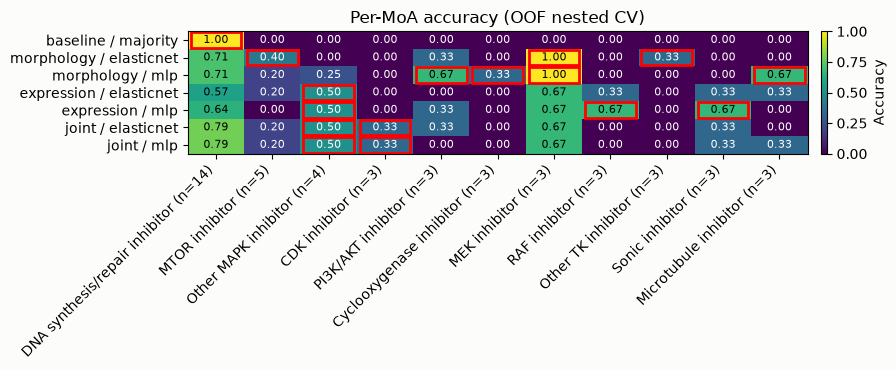

In [129]:
fig, ax = plt.subplots(
    figsize=(max(8, 0.55 * moa_class_accuracy.shape[1] + 3), 3.8)
)
im = ax.imshow(moa_class_accuracy.to_numpy(), aspect="auto", vmin=0, vmax=1, cmap="viridis")
ax.set_xticks(range(moa_class_accuracy.shape[1]))
ax.set_xticklabels(
    [f"{c} (n={int(class_counts[c])})" for c in moa_class_accuracy.columns],
    rotation=45,
    ha="right",
)
ax.set_yticks(range(moa_class_accuracy.shape[0]))
ax.set_yticklabels(moa_class_accuracy.index)
ax.set_title("Per-MoA accuracy (OOF nested CV)")

# For each column, find the row index of the maximal value (could be multiple maxima in case of ties).
highlighted_cells = []
for j in range(moa_class_accuracy.shape[1]):
    col = moa_class_accuracy.iloc[:, j]
    # Ignore columns fully-NaN
    if col.notna().any():
        max_val = np.nanmax(col.values)
        row_idxs = np.where(col.values == max_val)[0]
        for i in row_idxs:
            highlighted_cells.append((i, j))

# Draw all cell values, and outline best-per-column with a rectangle
for i in range(moa_class_accuracy.shape[0]):
    for j in range(moa_class_accuracy.shape[1]):
        val = moa_class_accuracy.iloc[i, j]
        if np.isnan(val):
            continue
        ax.text(
            j, i, f"{val:.2f}",
            ha="center", va="center",
            color="white" if val < 0.55 else "black",
            fontsize=8,
        )

# Draw rectangle around the max in each column
for (i, j) in highlighted_cells:
    rect = plt.Rectangle(
        (j - 0.45, i - 0.45), 0.9, 0.9,
        edgecolor="red", linewidth=2, facecolor="none"
    )
    ax.add_patch(rect)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Accuracy")
fig.tight_layout()
plt.show()

In [136]:
# supervised_drugs = moa_shared[supervised_mask].index.tolist()
# true_moa = encoder.inverse_transform(y)

# moa_oof_detail = pd.DataFrame(
#     {
#         "drug": supervised_drugs,
#         "true_moa": true_moa,
#         **{
#             row: encoder.inverse_transform(pred)
#             for row, pred in oof_by_row.items()
#         },
#     }
# )

# for row in row_order:
#     pred = moa_oof_detail[row].to_numpy()
#     correct_mask = pred == true_moa
#     correct = moa_oof_detail.loc[correct_mask, ["drug", "true_moa"]].sort_values(
#         ["true_moa", "drug"]
#     )
#     incorrect = (
#         moa_oof_detail.loc[~correct_mask, ["drug", "true_moa"]]
#         .assign(predicted_moa=pred[~correct_mask])
#         .sort_values(["true_moa", "drug"])
#     )

#     print(f"\n=== {row} ===")
#     print(f"correct ({len(correct)}/{len(moa_oof_detail)}):")
#     if len(correct):
#         print(
#             "\n".join(
#                 f"  {r.drug}  [{r.true_moa}]"
#                 for r in correct.itertuples(index=False)
#             )
#         )
#     else:
#         print("  (none)")
#     print(f"incorrect ({len(incorrect)}/{len(moa_oof_detail)}):")
#     if len(incorrect):
#         print(
#             "\n".join(
#                 f"  {r.drug}  true={r.true_moa}  pred={r.predicted_moa}"
#                 for r in incorrect.itertuples(index=False)
#             )
#         )
#     else:
#         print("  (none)")

# moa_oof_detail

## Supervised target prediction

Probes-drugs target table (`pd_export_…_targets_standardized.csv`). Gene-level
primary labels are too sparse for stratified CV on n=119 (almost all singletons),
so two complementary tasks:

1. **GTOPDB Level 2** (target family of the most potent human single-protein
   hit) — single-label, same nested elastic-net / MLP setup as MoA.
2. **Multi-label gene targets** — human single-protein genes annotated for
   ≥`MIN_GENE_SUPPORT` compounds (top `MAX_GENES_EVAL` by support); One-vs-Rest
   elastic-net / MLP; OOF macro AUROC and per-gene AUROC heatmap.

In [131]:
TARGETS_CSV = os.path.join(
    ANNOTATION_DIR, "pd_export_04_2022_2464_targets_standardized.csv"
)
targets_raw = pd.read_csv(TARGETS_CSV)
pdid_by_drug = emb_morph.obs["Metadata_pdid"].astype(str)
assert list(pdid_by_drug.index) == shared_compounds

tgt = targets_raw.loc[
    targets_raw["pdid"].astype(str).isin(set(pdid_by_drug))
].copy()
tgt["human_flag"] = tgt["human"].astype(str).isin(["1", "True", "true"])
tgt = tgt.loc[
    tgt["human_flag"]
    & (tgt["target_type"] == "single protein")
    & tgt["gene_name"].notna()
    & (tgt["gene_name"].astype(str).str.len() > 0)
].copy()
tgt["activity"] = tgt["activity_biochemical"].fillna(tgt["activity_cell"])

# Primary target family: highest-potency human single-protein annotation per compound.
primary = (
    tgt.sort_values("activity", ascending=False, na_position="last")
    .groupby("pdid", as_index=False)
    .first()
)
primary["drug"] = primary["pdid"].map(
    {str(p): d for d, p in pdid_by_drug.items()}
)
primary = primary.dropna(subset=["drug"]).set_index("drug")

family_col = "GTOPDB [LEVEL 2]"
family_all = primary[family_col].astype(str).reindex(shared_compounds)
family_all = family_all.where(family_all.notna() & ~family_all.isin(["nan", "None"]), other=np.nan)

MIN_CLASS_SIZE_TGT = 3
fam_counts_all = family_all.dropna().value_counts()
keep_families = fam_counts_all[fam_counts_all >= MIN_CLASS_SIZE_TGT].index
family_mask = family_all.isin(keep_families)

y_fam_raw = family_all[family_mask].to_numpy()
family_encoder = LabelEncoder()
y_fam = family_encoder.fit_transform(y_fam_raw)
family_counts = pd.Series(y_fam_raw).value_counts().sort_values(ascending=False)
print(
    f"GTOPDB L2 set: {len(y_fam)} compounds, {len(family_encoder.classes_)} families "
    f"(dropped {family_all.isna().sum()} unlabeled, "
    f"{((family_all.notna()) & ~family_mask).sum()} in families <{MIN_CLASS_SIZE_TGT})"
)
print(family_counts.to_string())

spaces_fam: dict[str, np.ndarray] = {
    "morphology": morph_z.to_numpy()[family_mask.to_numpy()],
    "expression": rna_z.to_numpy()[family_mask.to_numpy()],
    "joint": joint_z[family_mask.to_numpy()],
}

n_splits_fam = min(5, int(family_counts.min()))
outer_cv_fam = StratifiedKFold(
    n_splits=n_splits_fam, shuffle=True, random_state=RANDOM_STATE
)


def _inner_cv_fam(y_train: np.ndarray) -> StratifiedKFold:
    min_count = int(np.min(np.bincount(y_train)))
    k = max(2, min(3, min_count))
    return StratifiedKFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)


def fit_elasticnet_fam(X_train: np.ndarray, y_train: np.ndarray) -> LogisticRegressionCV:
    return LogisticRegressionCV(
        penalty="elasticnet",
        solver="saga",
        l1_ratios=[0.15, 0.5, 0.85],
        Cs=8,
        cv=_inner_cv_fam(y_train),
        scoring="f1_macro",
        max_iter=5000,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ).fit(X_train, y_train)


def fit_mlp_fam(X_train: np.ndarray, y_train: np.ndarray) -> MLPClassifier:
    search = GridSearchCV(
        MLPClassifier(
            activation="relu",
            solver="adam",
            max_iter=400,
            random_state=RANDOM_STATE,
        ),
        param_grid={
            "hidden_layer_sizes": [(32,), (64, 32)],
            "alpha": [1e-4, 1e-3],
        },
        cv=_inner_cv_fam(y_train),
        scoring="f1_macro",
        n_jobs=-1,
        refit=True,
    )
    search.fit(X_train, y_train)
    return search.best_estimator_


def oof_pred_fam(X: np.ndarray, y: np.ndarray, fit_fn) -> np.ndarray:
    pred = np.empty(len(y), dtype=int)
    for train_idx, test_idx in outer_cv_fam.split(X, y):
        pred[test_idx] = fit_fn(X[train_idx], y[train_idx]).predict(X[test_idx])
    return pred


def majority_oof_fam(y: np.ndarray) -> np.ndarray:
    pred = np.empty(len(y), dtype=int)
    dummy = np.zeros((len(y), 1))
    for train_idx, test_idx in outer_cv_fam.split(dummy, y):
        pred[test_idx] = int(np.bincount(y[train_idx]).argmax())
    return pred


def per_family_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> pd.Series:
    rows = {}
    for code, name in enumerate(family_encoder.classes_):
        mask = y_true == code
        rows[name] = float((y_pred[mask] == code).mean()) if mask.any() else np.nan
    return pd.Series(rows, name="accuracy")


fam_row_order = [
    "baseline / majority",
    "morphology / elasticnet",
    "morphology / mlp",
    "expression / elasticnet",
    "expression / mlp",
    "joint / elasticnet",
    "joint / mlp",
]
fam_oof: dict[str, np.ndarray] = {"baseline / majority": majority_oof_fam(y_fam)}
for space_name, X in spaces_fam.items():
    for model_name, fit_fn in (("elasticnet", fit_elasticnet_fam), ("mlp", fit_mlp_fam)):
        fam_oof[f"{space_name} / {model_name}"] = oof_pred_fam(X, y_fam, fit_fn)

target_family_accuracy = pd.DataFrame(
    {row: per_family_accuracy(y_fam, pred) for row, pred in fam_oof.items()}
).T.reindex(fam_row_order)
target_family_accuracy = target_family_accuracy[family_counts.index.tolist()]
print(f"\\nPer-family OOF accuracy ({n_splits_fam}-fold nested CV):")
target_family_accuracy.round(3)

GTOPDB L2 set: 105 compounds, 10 families (dropped 3 unlabeled, 11 in families <3)
Kinase                                        36
Oxidoreductase                                12
Family A G protein-coupled receptor           11
Nuclear receptor                              10
Cytochrome P450                                9
Transferase                                    8
Electrochemical transporter                    7
Protease                                       6
Frizzled family G protein-coupled receptor     3
Hydrolase                                      3
\nPer-family OOF accuracy (3-fold nested CV):


,Kinase,Oxidoreductase,Family A G protein-coupled receptor,Nuclear receptor,Cytochrome P450,Transferase,Electrochemical transporter,Protease,Frizzled family G protein-coupled receptor,Hydrolase
baseline / majority,1.000,0.00,0.000,0.0,0.000,0.000,0.0,0.000,0.0,0.0
morphology / elasticnet,0.444,0.00,0.000,0.2,0.000,0.000,0.0,0.333,0.0,0.0
morphology / mlp,0.556,0.25,0.091,0.3,0.111,0.000,0.0,0.167,0.0,0.0
expression / elasticnet,0.722,0.25,0.000,0.6,0.000,0.125,0.0,0.000,0.0,0.0
expression / mlp,0.667,0.25,0.000,0.4,0.111,0.000,0.0,0.000,0.0,0.0
joint / elasticnet,0.889,0.25,0.182,0.5,0.111,0.000,0.0,0.000,0.0,0.0
joint / mlp,0.750,0.25,0.273,0.5,0.111,0.000,0.0,0.333,0.0,0.0


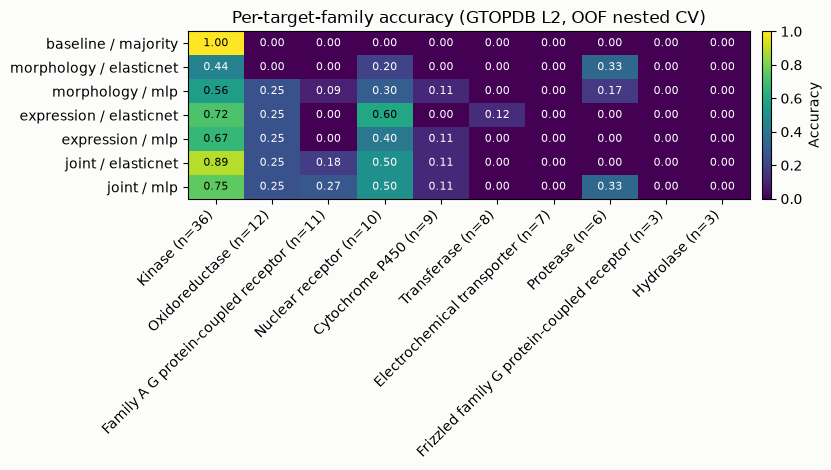

In [ ]:
fig, ax = plt.subplots(
    figsize=(max(8, 0.55 * target_family_accuracy.shape[1] + 3), 4.8)
)
im = ax.imshow(
    target_family_accuracy.to_numpy(), aspect="auto", vmin=0, vmax=1, cmap="viridis"
)
ax.set_xticks(range(target_family_accuracy.shape[1]))
ax.set_xticklabels(
    [f"{c} (n={int(family_counts[c])})" for c in target_family_accuracy.columns],
    rotation=45,
    ha="right",
)
ax.set_yticks(range(target_family_accuracy.shape[0]))
ax.set_yticklabels(target_family_accuracy.index)
ax.set_title("Per-target-family accuracy (GTOPDB L2, OOF nested CV)")
for i in range(target_family_accuracy.shape[0]):
    for j in range(target_family_accuracy.shape[1]):
        val = target_family_accuracy.iloc[i, j]
        if np.isnan(val):
            continue
        ax.text(
            j, i, f"{val:.2f}",
            ha="center", va="center",
            color="white" if val < 0.55 else "black",
            fontsize=8,
        )
cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Accuracy")
fig.tight_layout()
plt.show()



In [133]:
# Multi-label gene targets: genes annotated for enough compounds among the 119.
MIN_GENE_SUPPORT = 8
MAX_GENES_EVAL = 15  # cap for nested OvR runtime
gene_by_pdid = (
    tgt.groupby(["pdid", "gene_name"], observed=True)
    .size()
    .reset_index(name="n_annots")
)
gene_support = gene_by_pdid.groupby("gene_name")["pdid"].nunique()
keep_genes = (
    gene_support[gene_support >= MIN_GENE_SUPPORT]
    .sort_values(ascending=False)
    .head(MAX_GENES_EVAL)
)
print(
    f"Multi-label genes: top {len(keep_genes)} with support >={MIN_GENE_SUPPORT} "
    f"(top: {', '.join(f'{g}={n}' for g, n in keep_genes.head(8).items())})"
)

pdid_to_drug = {str(p): d for d, p in pdid_by_drug.items()}
Y_gene = pd.DataFrame(0, index=shared_compounds, columns=keep_genes.index.tolist(), dtype=int)
for pdid, gene in gene_by_pdid.loc[
    gene_by_pdid["gene_name"].isin(keep_genes.index), ["pdid", "gene_name"]
].itertuples(index=False):
    drug = pdid_to_drug.get(str(pdid))
    if drug is not None:
        Y_gene.loc[drug, gene] = 1

gene_mask = Y_gene.sum(axis=1) > 0
Y_ml = Y_gene.loc[gene_mask].to_numpy()
gene_names = Y_gene.columns.tolist()
spaces_ml: dict[str, np.ndarray] = {
    "morphology": morph_z.to_numpy()[gene_mask.to_numpy()],
    "expression": rna_z.to_numpy()[gene_mask.to_numpy()],
    "joint": joint_z[gene_mask.to_numpy()],
}
print(
    f"Multi-label set: {gene_mask.sum()} compounds x {len(gene_names)} genes; "
    f"mean positives/compound={Y_ml.sum(axis=1).mean():.1f}"
)

N_OUTER_ML = 5
outer_cv_ml = KFold(n_splits=N_OUTER_ML, shuffle=True, random_state=RANDOM_STATE)


def _binary_inner_cv(y_train: np.ndarray) -> StratifiedKFold | KFold:
    pos = int(y_train.sum())
    neg = int(len(y_train) - pos)
    k = max(2, min(3, pos, neg))
    if pos >= k and neg >= k:
        return StratifiedKFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)
    return KFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)


def fit_elasticnet_ml(X_train: np.ndarray, y_train: np.ndarray) -> LogisticRegressionCV:
    return LogisticRegressionCV(
        penalty="elasticnet",
        solver="saga",
        l1_ratios=[0.15, 0.5, 0.85],
        Cs=6,
        cv=_binary_inner_cv(y_train),
        scoring="roc_auc",
        max_iter=4000,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ).fit(X_train, y_train)


def fit_mlp_ml(X_train: np.ndarray, y_train: np.ndarray) -> MLPClassifier:
    search = GridSearchCV(
        MLPClassifier(
            activation="relu",
            solver="adam",
            max_iter=400,
            random_state=RANDOM_STATE,
        ),
        param_grid={
            "hidden_layer_sizes": [(32,), (64,)],
            "alpha": [1e-4, 1e-3],
        },
        cv=_binary_inner_cv(y_train),
        scoring="roc_auc",
        n_jobs=-1,
        refit=True,
    )
    search.fit(X_train, y_train)
    return search.best_estimator_


def oof_proba_binary(X: np.ndarray, y: np.ndarray, fit_fn) -> np.ndarray:
    proba = np.full(len(y), np.nan)
    for train_idx, test_idx in outer_cv_ml.split(X):
        y_tr = y[train_idx]
        if y_tr.min() == y_tr.max():
            proba[test_idx] = float(y_tr.mean())
            continue
        try:
            model = fit_fn(X[train_idx], y_tr)
            proba[test_idx] = model.predict_proba(X[test_idx])[:, 1]
        except Exception:
            proba[test_idx] = float(y_tr.mean())
    return proba


def prevalence_baseline_proba(y: np.ndarray) -> np.ndarray:
    proba = np.empty(len(y), dtype=float)
    dummy = np.zeros((len(y), 1))
    for train_idx, test_idx in outer_cv_ml.split(dummy):
        proba[test_idx] = float(y[train_idx].mean())
    return proba


def safe_auroc(y_true: np.ndarray, y_score: np.ndarray) -> float:
    if y_true.min() == y_true.max() or not np.isfinite(y_score).all():
        return float("nan")
    return float(roc_auc_score(y_true, y_score))


ml_rows: list[dict] = []
gene_auroc: dict[str, pd.Series] = {}

base_aurocs = []
for j, gene in enumerate(gene_names):
    yj = Y_ml[:, j]
    auc = safe_auroc(yj, prevalence_baseline_proba(yj))
    base_aurocs.append(auc)
    ml_rows.append(
        {"space": "baseline", "model": "prevalence", "gene": gene, "auroc": auc}
    )
gene_auroc["baseline / prevalence"] = pd.Series(base_aurocs, index=gene_names)

for space_name, X in spaces_ml.items():
    for model_name, fit_fn in (("elasticnet", fit_elasticnet_ml), ("mlp", fit_mlp_ml)):
        aurocs = []
        for j, gene in enumerate(gene_names):
            yj = Y_ml[:, j]
            auc = safe_auroc(yj, oof_proba_binary(X, yj, fit_fn))
            aurocs.append(auc)
            ml_rows.append(
                {
                    "space": space_name,
                    "model": model_name,
                    "gene": gene,
                    "auroc": auc,
                }
            )
        gene_auroc[f"{space_name} / {model_name}"] = pd.Series(aurocs, index=gene_names)
        print(f"done {space_name} / {model_name}: macro AUROC={np.nanmean(aurocs):.3f}")

target_gene_auroc = pd.DataFrame(gene_auroc).T
# Order genes by support (most common first); cap heatmap width.
top_genes = keep_genes.head(min(20, len(keep_genes))).index.tolist()
target_gene_auroc_plot = target_gene_auroc[top_genes]
target_gene_macro = target_gene_auroc.mean(axis=1).rename("macro_auroc")
print("\\nMacro AUROC over genes:")
print(target_gene_macro.round(3).to_string())
target_gene_macro.round(3)

Multi-label genes: top 15 with support >=8 (top: LMNA=35, CYP3A4=32, MAPT=24, ABCB11=21, ALDH1A1=20, BLM=18, KCNH2=16, CYP2C9=16)
Multi-label set: 66 compounds x 15 genes; mean positives/compound=4.3
done morphology / elasticnet: macro AUROC=0.526
done morphology / mlp: macro AUROC=0.502
done expression / elasticnet: macro AUROC=0.489
done expression / mlp: macro AUROC=0.506
done joint / elasticnet: macro AUROC=0.515
done joint / mlp: macro AUROC=0.536
\nMacro AUROC over genes:
baseline / prevalence      0.376
morphology / elasticnet    0.526
morphology / mlp           0.502
expression / elasticnet    0.489
expression / mlp           0.506
joint / elasticnet         0.515
joint / mlp                0.536


baseline / prevalence      0.376
morphology / elasticnet    0.526
morphology / mlp           0.502
expression / elasticnet    0.489
expression / mlp           0.506
joint / elasticnet         0.515
joint / mlp                0.536
Name: macro_auroc, dtype: float64

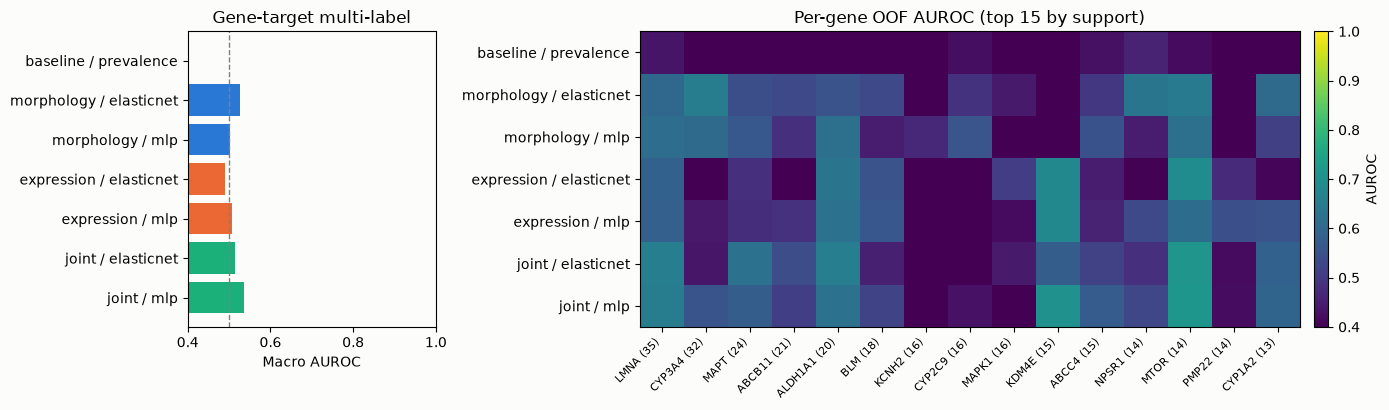

In [134]:
fig, axes = plt.subplots(
    1, 2, figsize=(14, 4.2), gridspec_kw={"width_ratios": [1, 2.8]}
)

# Macro AUROC bars
macro = target_gene_macro.reindex(
    [
        "baseline / prevalence",
        "morphology / elasticnet",
        "morphology / mlp",
        "expression / elasticnet",
        "expression / mlp",
        "joint / elasticnet",
        "joint / mlp",
    ]
)
colors = ["#8c8c8c", "#2a78d6", "#2a78d6", "#eb6834", "#eb6834", "#1baf7a", "#1baf7a"]
axes[0].barh(range(len(macro)), macro.to_numpy(), color=colors)
axes[0].set_yticks(range(len(macro)))
axes[0].set_yticklabels(macro.index)
axes[0].invert_yaxis()
axes[0].set_xlim(0.4, 1.0)
axes[0].axvline(0.5, color="gray", ls="--", lw=1)
axes[0].set_xlabel("Macro AUROC")
axes[0].set_title("Gene-target multi-label")

im = axes[1].imshow(
    target_gene_auroc_plot.to_numpy(), aspect="auto", vmin=0.4, vmax=1.0, cmap="viridis"
)
axes[1].set_xticks(range(target_gene_auroc_plot.shape[1]))
axes[1].set_xticklabels(
    [f"{g} ({int(keep_genes[g])})" for g in target_gene_auroc_plot.columns],
    rotation=45,
    ha="right",
    fontsize=8,
)
axes[1].set_yticks(range(target_gene_auroc_plot.shape[0]))
axes[1].set_yticklabels(target_gene_auroc_plot.index)
axes[1].set_title(f"Per-gene OOF AUROC (top {target_gene_auroc_plot.shape[1]} by support)")
cbar = fig.colorbar(im, ax=axes[1], fraction=0.03, pad=0.02)
cbar.set_label("AUROC")
fig.tight_layout()
plt.show()

## Predict gene-set enrichment (heat-shock/UPR & NF-kB)

The expression-only UMAP in the integration notebook splits into two blobs along
PC1 that mix MoA labels — a **proteotoxic stress** axis (heat-shock /
unfolded-protein response + NF-kB), not batch or MoA.

Here we turn that into a supervised task:

1. Pseudobulk `expression_hepg2.h5ad` to one mean profile per compound.
2. Score curated gene sets with `scanpy.tl.score_genes` (set mean minus
   expression-matched controls):
   - **`hsr_upr`**: heat-shock / UPR (HSPA1A/B, DNAJB1, XBP1, DDIT3, …)
   - **`nfkb`**: NF-kB stress signaling (NFKBIA, TNFAIP3, BIRC3, REL, …)
3. Nested-CV regress those scores from morphology / expression / joint
   embeddings (elastic net + MLP + mean baseline).

Expression→score is partly circular (same modality); the cross-modal test is
whether **morphology** (and joint) recover the stress state.

In [153]:
# Curated sets seeded by PC1 stressed-pole genes from the integration notebook,
# expanded with canonical HSR/UPR and NF-kB members present in the Tahoe panel.
GENE_SETS: dict[str, list[str]] = {
    "hsr_upr": [
        "HSPA1A", "HSPA1B", "HSPA6", "HSPA8", "HSPA5",
        "HSP90AA1", "HSP90AB1", "HSP90B1", "HSPH1", "HSPB1",
        "DNAJB1", "DNAJA1", "DNAJB4",
        "XBP1", "DDIT3", "ATF4", "ATF6", "ERN1", "HERPUD1", "PPP1R15A",
    ],
    "nfkb": [
        "NFKBIA", "NFKBIE", "NFKB1", "NFKB2", "RELA", "RELB", "REL",
        "TNFAIP3", "BIRC2", "BIRC3", "CYLD", "TRAF1", "TRAF2",
        "CXCL8", "ICAM1", "SOD2",
    ],
}

rna_cells = ad.read_h5ad(EXPR_H5AD, backed="r")
present = set(rna_cells.var_names)
for name, genes in GENE_SETS.items():
    hit = [g for g in genes if g in present]
    miss = [g for g in genes if g not in present]
    print(f"{name}: {len(hit)}/{len(genes)} genes in panel" + (f" (missing {miss})" if miss else ""))
    GENE_SETS[name] = hit

needed = set().union(*GENE_SETS.values())
rng = np.random.default_rng(RANDOM_STATE)
ctrl_pool = [g for g in rna_cells.var_names if g not in needed]
ctrl = set(rng.choice(ctrl_pool, size=min(500, len(ctrl_pool)), replace=False))
keep_genes = sorted(needed | ctrl)

print(f"Loading {len(keep_genes)} genes x {rna_cells.n_obs:,} cells for pseudobulk...")
rna_sub = rna_cells[:, keep_genes].to_memory()
pb = sc.get.aggregate(rna_sub, by="Metadata_Drug", func="mean")
rna_pb = ad.AnnData(
    np.asarray(pb.layers["mean"]),
    obs=pb.obs.copy(),
    var=pb.var.copy(),
)
# Aggregate keys the drug in obs; align index to drug name.
if "Metadata_Drug" in rna_pb.obs:
    rna_pb.obs_names = rna_pb.obs["Metadata_Drug"].astype(str).to_numpy()

for name, genes in GENE_SETS.items():
    sc.tl.score_genes(
        rna_pb,
        gene_list=genes,
        score_name=name,
        ctrl_size=50,
        use_raw=False,
        random_state=RANDOM_STATE,
    )

y_geneset = rna_pb.obs[list(GENE_SETS)].reindex(shared_compounds)
print("Compound-level enrichment scores:")
print(y_geneset.describe().round(3).T.to_string())
print(
    f"Spearman(hsr_upr, nfkb) = "
    f"{y_geneset['hsr_upr'].corr(y_geneset['nfkb'], method='spearman'):.3f}"
)

gs_path = "./data/compound_embeddings/geneset_enrichment_scores.parquet"
y_geneset.to_parquet(gs_path)
print(f"Wrote {gs_path}")
y_geneset.head()

hsr_upr: 20/20 genes in panel
nfkb: 16/16 genes in panel
Loading 536 genes x 384,533 cells for pseudobulk...
Compound-level enrichment scores:
         count   mean    std    min    25%    50%    75%    max
hsr_upr  119.0  0.269  0.045  0.188  0.248  0.261  0.278  0.629
nfkb     119.0  0.053  0.049 -0.057  0.021  0.050  0.079  0.422
Spearman(hsr_upr, nfkb) = -0.174
Wrote ./data/compound_embeddings/geneset_enrichment_scores.parquet


,hsr_upr,nfkb
18β-Glycyrrhetinic acid,0.241976,0.020855
5-Fluorouracil,0.248986,0.072331
8-Hydroxyquinoline,0.257523,-0.010893
AT7519,0.285016,0.025009
AZD-8055,0.286844,0.023988


In [155]:
# Nested-CV regression of enrichment scores from each embedding space.
gs_order = [d for d in shared_compounds if d in y_geneset.dropna().index]
y_gs = y_geneset.loc[gs_order]
X_gs: dict[str, np.ndarray] = {
    "morphology": morph_z.loc[gs_order].to_numpy(),
    "expression": rna_z.loc[gs_order].to_numpy(),
    "joint": pd.DataFrame(joint_z, index=shared_compounds).loc[gs_order].to_numpy(),
}
gs_targets = list(y_gs.columns)
print(f"Predicting {gs_targets} for n={len(gs_order)} compounds")

N_OUTER_GS = 5
outer_cv_gs = KFold(n_splits=N_OUTER_GS, shuffle=True, random_state=RANDOM_STATE)
inner_cv_gs = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)


def fit_elasticnet_gs(X_train: np.ndarray, y_train: np.ndarray) -> ElasticNetCV:
    return ElasticNetCV(
        l1_ratio=[0.15, 0.5, 0.85],
        # alphas=None,
        cv=inner_cv_gs,
        max_iter=5000,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ).fit(X_train, y_train)


def fit_mlp_gs(X_train: np.ndarray, y_train: np.ndarray) -> MLPRegressor:
    search = GridSearchCV(
        MLPRegressor(
            activation="relu",
            solver="adam",
            max_iter=800,
            random_state=RANDOM_STATE,
        ),
        param_grid={
            "hidden_layer_sizes": [(32,), (64, 32)],
            "alpha": [1e-4, 1e-3],
        },
        cv=inner_cv_gs,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
        refit=True,
    )
    search.fit(X_train, y_train)
    return search.best_estimator_


def oof_regression_gs(X: np.ndarray, y: np.ndarray, fit_fn) -> np.ndarray:
    pred = np.empty(len(y), dtype=float)
    for train_idx, test_idx in outer_cv_gs.split(X):
        pred[test_idx] = fit_fn(X[train_idx], y[train_idx]).predict(X[test_idx])
    return pred


def mean_baseline_oof_gs(y: np.ndarray) -> np.ndarray:
    pred = np.empty(len(y), dtype=float)
    dummy = np.zeros((len(y), 1))
    for train_idx, test_idx in outer_cv_gs.split(dummy):
        pred[test_idx] = float(np.mean(y[train_idx]))
    return pred


def regression_metrics_gs(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    if np.allclose(y_true, y_true[0]):
        rho = float("nan")
    else:
        rho = float(spearmanr(y_true, y_pred).correlation)
    return {
        "spearman": rho,
        "r2": float(r2_score(y_true, y_pred)),
        "mae": float(mean_absolute_error(y_true, y_pred)),
    }


gs_rows: list[dict] = []
gs_oof: dict[tuple[str, str, str], np.ndarray] = {}

for target in gs_targets:
    y = y_gs[target].to_numpy(dtype=float)
    base_pred = mean_baseline_oof_gs(y)
    gs_oof[("baseline", "mean", target)] = base_pred
    for metric, val in regression_metrics_gs(y, base_pred).items():
        gs_rows.append(
            {"target": target, "space": "baseline", "model": "mean", "metric": metric, "value": val}
        )

    for space_name, X in X_gs.items():
        for model_name, fit_fn in (("elasticnet", fit_elasticnet_gs), ("mlp", fit_mlp_gs)):
            pred = oof_regression_gs(X, y, fit_fn)
            gs_oof[(space_name, model_name, target)] = pred
            for metric, val in regression_metrics_gs(y, pred).items():
                gs_rows.append(
                    {
                        "target": target,
                        "space": space_name,
                        "model": model_name,
                        "metric": metric,
                        "value": val,
                    }
                )
    print(f"done {target}")

geneset_metrics = pd.DataFrame(gs_rows)
geneset_spearman = (
    geneset_metrics.loc[geneset_metrics["metric"] == "spearman"]
    .assign(label=lambda d: d["space"] + " / " + d["model"])
    .pivot(index="label", columns="target", values="value")
)
gs_row_order = [
    "baseline / mean",
    "morphology / elasticnet",
    "morphology / mlp",
    "expression / elasticnet",
    "expression / mlp",
    "joint / elasticnet",
    "joint / mlp",
]
geneset_spearman = geneset_spearman.reindex(index=gs_row_order, columns=gs_targets)
print("OOF Spearman rho:")
geneset_spearman.round(3)

Predicting ['hsr_upr', 'nfkb'] for n=119 compounds
done hsr_upr
done nfkb
OOF Spearman rho:


target,hsr_upr,nfkb
label,,
baseline / mean,-0.134,-0.105
morphology / elasticnet,0.120,-0.053
morphology / mlp,0.054,-0.120
expression / elasticnet,0.930,0.967
expression / mlp,0.029,0.173
joint / elasticnet,0.925,0.926
joint / mlp,0.245,0.476


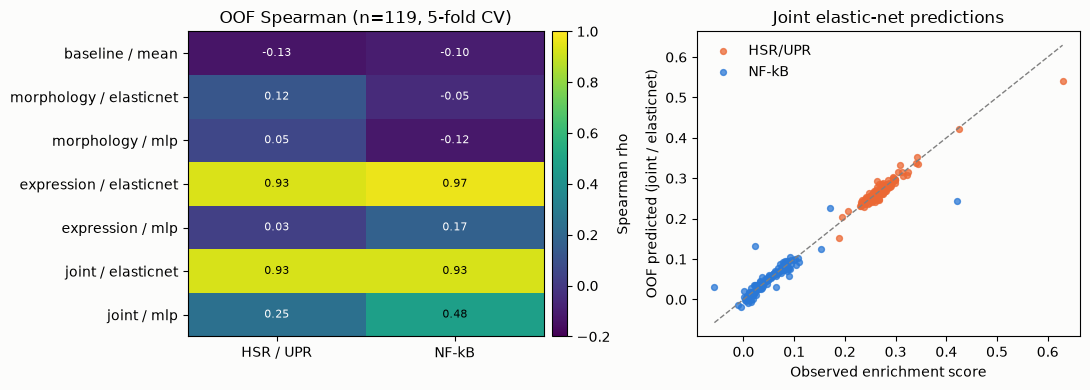

OOF R2:


target,hsr_upr,nfkb
label,,
baseline / mean,-0.019,-0.015
morphology / elasticnet,-0.319,-0.016
morphology / mlp,-23.642,-28.488
expression / elasticnet,0.901,0.898
expression / mlp,-27.225,-21.897
joint / elasticnet,0.926,0.766
joint / mlp,-2.324,-1.409


In [156]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))

im = axes[0].imshow(
    geneset_spearman.to_numpy(), aspect="auto", vmin=-0.2, vmax=1.0, cmap="viridis"
)
axes[0].set_xticks(range(len(geneset_spearman.columns)))
axes[0].set_xticklabels(
    [{"hsr_upr": "HSR / UPR", "nfkb": "NF-kB"}[c] for c in geneset_spearman.columns]
)
axes[0].set_yticks(range(len(geneset_spearman.index)))
axes[0].set_yticklabels(geneset_spearman.index)
axes[0].set_title(f"OOF Spearman (n={len(gs_order)}, {N_OUTER_GS}-fold CV)")
for i in range(geneset_spearman.shape[0]):
    for j in range(geneset_spearman.shape[1]):
        val = geneset_spearman.iloc[i, j]
        if np.isnan(val):
            continue
        axes[0].text(
            j, i, f"{val:.2f}",
            ha="center", va="center",
            color="white" if val < 0.4 else "black",
            fontsize=8,
        )
fig.colorbar(im, ax=axes[0], fraction=0.05, pad=0.02).set_label("Spearman rho")

lo, hi = np.inf, -np.inf
for target, color, label in (
    ("hsr_upr", "#eb6834", "HSR/UPR"),
    ("nfkb", "#2a78d6", "NF-kB"),
):
    y_true = y_gs[target].to_numpy()
    y_pred = gs_oof[("joint", "elasticnet", target)]
    axes[1].scatter(y_true, y_pred, s=18, alpha=0.75, c=color, label=label)
    lo = min(lo, y_true.min(), y_pred.min())
    hi = max(hi, y_true.max(), y_pred.max())
axes[1].plot([lo, hi], [lo, hi], color="gray", ls="--", lw=1)
axes[1].set_xlabel("Observed enrichment score")
axes[1].set_ylabel("OOF predicted (joint / elasticnet)")
axes[1].set_title("Joint elastic-net predictions")
axes[1].legend(frameon=False)

fig.tight_layout()
plt.show()

geneset_r2 = (
    geneset_metrics.loc[geneset_metrics["metric"] == "r2"]
    .assign(label=lambda d: d["space"] + " / " + d["model"])
    .pivot(index="label", columns="target", values="value")
    .reindex(index=gs_row_order, columns=gs_targets)
)
print("OOF R2:")
geneset_r2.round(3)